# Relational Deep Learning (RDL)

## Learning Objectives

1. **Motivate** learning on relational databases: most enterprise ML data lives in multi-table schemas
2. **Define** the relational graph: how tables become nodes and foreign-key relationships become edges
3. **Explain** the RDL pipeline: schema → graph → GNN → predictions
4. **Implement** a small multi-table dataset as a graph and run message passing
5. **Discuss** the RelBench benchmark and the relbench/PyG ecosystem


## Motivation

### Relational Data is Ubiquitous

Most production ML systems are built on relational databases (RDBs):
- E-commerce: `users`, `orders`, `products`, `reviews`
- Healthcare: `patients`, `visits`, `diagnoses`, `medications`
- Finance: `accounts`, `transactions`, `merchants`

Traditional approach: hand-craft aggregate features by joining tables → tedious, leaks information, misses patterns.

**Relational Deep Learning** (Fey et al., 2023): learn directly on the relational structure by converting it to a heterogeneous graph.

### From Relational Schema to Graph

Conversion rules:
1. **Each row** in a table → one node
2. **Each foreign key** relationship → one directed edge
3. **Column values** → node feature vector (after encoding)
4. **Target**: predict a property of a seed entity (e.g., predict customer churn)

### Heterogeneous Graph

A **heterogeneous graph** $\mathcal{G} = (V, E, \mathcal{T}_V, \mathcal{T}_E)$ where nodes and edges have types:
- Node types $\mathcal{T}_V$: one per table
- Edge types $\mathcal{T}_E$: one per foreign-key relationship (plus reverse)
- Each type has its own feature dimension and its own weight matrices

### Message Passing on Heterogeneous Graphs

For each edge type $(\text{src\_type}, \text{rel}, \text{dst\_type})$:
$$m_v^{\text{rel}} = \text{AGG}\!\left(\left\{W_{\text{rel}} h_u : u \in \mathcal{N}^{\text{rel}}(v)\right\}\right)$$
$$h_v = \sigma\!\left(W_0 h_v + \sum_{\text{rel}} m_v^{\text{rel}}\right)$$

This is the **R-GCN** (Schlichtkrull et al., 2018) update rule.


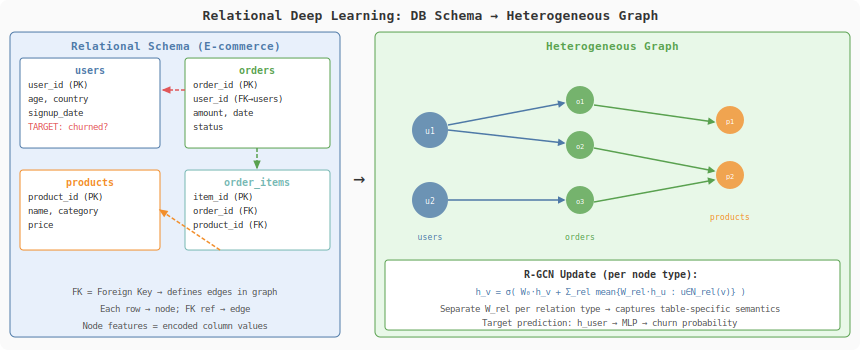

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="860" height="350" font-family="monospace" font-size="11">
  <rect width="860" height="350" fill="#fafafa" rx="8"/>
  <text x="430" y="20" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">Relational Deep Learning: DB Schema → Heterogeneous Graph</text>

  <!-- LEFT: schema tables -->
  <rect x="10" y="32" width="330" height="305" rx="5" fill="#e8f0fb" stroke="#4e79a7"/>
  <text x="175" y="50" text-anchor="middle" fill="#4e79a7" font-weight="bold">Relational Schema (E-commerce)</text>

  <!-- Users table -->
  <rect x="20" y="58" width="140" height="90" rx="3" fill="#fff" stroke="#4e79a7"/>
  <text x="90" y="74" text-anchor="middle" fill="#4e79a7" font-weight="bold" font-size="10">users</text>
  <text x="28" y="88" fill="#333" font-size="9">user_id  (PK)</text>
  <text x="28" y="102" fill="#333" font-size="9">age, country</text>
  <text x="28" y="116" fill="#333" font-size="9">signup_date</text>
  <text x="28" y="130" fill="#e15759" font-size="9">TARGET: churned?</text>

  <!-- Orders table -->
  <rect x="185" y="58" width="145" height="90" rx="3" fill="#fff" stroke="#59a14f"/>
  <text x="257" y="74" text-anchor="middle" fill="#59a14f" font-weight="bold" font-size="10">orders</text>
  <text x="193" y="88" fill="#333" font-size="9">order_id  (PK)</text>
  <text x="193" y="102" fill="#333" font-size="9">user_id   (FK→users)</text>
  <text x="193" y="116" fill="#333" font-size="9">amount, date</text>
  <text x="193" y="130" fill="#333" font-size="9">status</text>

  <!-- Products table -->
  <rect x="20" y="170" width="140" height="80" rx="3" fill="#fff" stroke="#f28e2b"/>
  <text x="90" y="186" text-anchor="middle" fill="#f28e2b" font-weight="bold" font-size="10">products</text>
  <text x="28" y="200" fill="#333" font-size="9">product_id  (PK)</text>
  <text x="28" y="214" fill="#333" font-size="9">name, category</text>
  <text x="28" y="228" fill="#333" font-size="9">price</text>

  <!-- Order_items table -->
  <rect x="185" y="170" width="145" height="80" rx="3" fill="#fff" stroke="#76b7b2"/>
  <text x="257" y="186" text-anchor="middle" fill="#76b7b2" font-weight="bold" font-size="10">order_items</text>
  <text x="193" y="200" fill="#333" font-size="9">item_id      (PK)</text>
  <text x="193" y="214" fill="#333" font-size="9">order_id     (FK)</text>
  <text x="193" y="228" fill="#333" font-size="9">product_id   (FK)</text>

  <!-- FK arrows -->
  <line x1="185" y1="90" x2="163" y2="90" stroke="#e15759" stroke-width="1.5" stroke-dasharray="4,2" marker-end="url(#fk1)"/>
  <defs><marker id="fk1" markerWidth="6" markerHeight="5" refX="5" refY="2.5" orient="auto"><polygon points="0 0,6 2.5,0 5" fill="#e15759"/></marker></defs>
  <line x1="257" y1="148" x2="257" y2="168" stroke="#59a14f" stroke-width="1.5" stroke-dasharray="4,2" marker-end="url(#fk2)"/>
  <defs><marker id="fk2" markerWidth="6" markerHeight="5" refX="5" refY="2.5" orient="auto"><polygon points="0 0,6 2.5,0 5" fill="#59a14f"/></marker></defs>
  <line x1="220" y1="250" x2="160" y2="210" stroke="#f28e2b" stroke-width="1.5" stroke-dasharray="4,2" marker-end="url(#fk3)"/>
  <defs><marker id="fk3" markerWidth="6" markerHeight="5" refX="5" refY="2.5" orient="auto"><polygon points="0 0,6 2.5,0 5" fill="#f28e2b"/></marker></defs>

  <text x="175" y="295" text-anchor="middle" fill="#555" font-size="9">FK = Foreign Key → defines edges in graph</text>
  <text x="175" y="312" text-anchor="middle" fill="#555" font-size="9">Each row → node; FK ref → edge</text>
  <text x="175" y="329" text-anchor="middle" fill="#555" font-size="9">Node features = encoded column values</text>

  <!-- Arrow -->
  <text x="353" y="185" fill="#333" font-size="20">→</text>

  <!-- RIGHT: Heterogeneous graph -->
  <rect x="375" y="32" width="475" height="305" rx="5" fill="#e8f8e8" stroke="#59a14f"/>
  <text x="612" y="50" text-anchor="middle" fill="#59a14f" font-weight="bold">Heterogeneous Graph</text>

  <!-- User nodes -->
  <circle cx="430" cy="130" r="18" fill="#4e79a7" opacity="0.8"/><text x="430" y="134" text-anchor="middle" fill="white" font-size="8">u1</text>
  <circle cx="430" cy="200" r="18" fill="#4e79a7" opacity="0.8"/><text x="430" y="204" text-anchor="middle" fill="white" font-size="8">u2</text>
  <text x="430" y="240" text-anchor="middle" fill="#4e79a7" font-size="8">users</text>

  <!-- Order nodes -->
  <circle cx="580" cy="100" r="14" fill="#59a14f" opacity="0.8"/><text x="580" y="104" text-anchor="middle" fill="white" font-size="7">o1</text>
  <circle cx="580" cy="145" r="14" fill="#59a14f" opacity="0.8"/><text x="580" y="149" text-anchor="middle" fill="white" font-size="7">o2</text>
  <circle cx="580" cy="200" r="14" fill="#59a14f" opacity="0.8"/><text x="580" y="204" text-anchor="middle" fill="white" font-size="7">o3</text>
  <text x="580" y="240" text-anchor="middle" fill="#59a14f" font-size="8">orders</text>

  <!-- Product nodes -->
  <circle cx="730" cy="120" r="14" fill="#f28e2b" opacity="0.8"/><text x="730" y="124" text-anchor="middle" fill="white" font-size="7">p1</text>
  <circle cx="730" cy="175" r="14" fill="#f28e2b" opacity="0.8"/><text x="730" y="179" text-anchor="middle" fill="white" font-size="7">p2</text>
  <text x="730" y="220" text-anchor="middle" fill="#f28e2b" font-size="8">products</text>

  <!-- Edges user→order -->
  <line x1="448" y1="125" x2="564" y2="103" stroke="#4e79a7" stroke-width="1.5" marker-end="url(#e1)"/>
  <defs><marker id="e1" markerWidth="5" markerHeight="5" refX="4" refY="2.5" orient="auto"><polygon points="0 0,5 2.5,0 5" fill="#4e79a7"/></marker></defs>
  <line x1="448" y1="130" x2="564" y2="143" stroke="#4e79a7" stroke-width="1.5" marker-end="url(#e1)"/>
  <line x1="448" y1="200" x2="564" y2="200" stroke="#4e79a7" stroke-width="1.5" marker-end="url(#e1)"/>

  <!-- Edges order→product -->
  <line x1="594" y1="105" x2="714" y2="122" stroke="#59a14f" stroke-width="1.5" marker-end="url(#e2)"/>
  <defs><marker id="e2" markerWidth="5" markerHeight="5" refX="4" refY="2.5" orient="auto"><polygon points="0 0,5 2.5,0 5" fill="#59a14f"/></marker></defs>
  <line x1="594" y1="148" x2="714" y2="171" stroke="#59a14f" stroke-width="1.5" marker-end="url(#e2)"/>
  <line x1="594" y1="202" x2="714" y2="180" stroke="#59a14f" stroke-width="1.5" marker-end="url(#e2)"/>

  <!-- R-GCN legend -->
  <rect x="385" y="260" width="455" height="70" rx="3" fill="#fff" stroke="#59a14f"/>
  <text x="610" y="278" text-anchor="middle" fill="#333" font-size="10" font-weight="bold">R-GCN Update (per node type):</text>
  <text x="610" y="295" text-anchor="middle" fill="#4e79a7" font-size="9">h_v = σ( W₀·h_v + Σ_rel mean{W_rel·h_u : u∈N_rel(v)} )</text>
  <text x="610" y="312" text-anchor="middle" fill="#555" font-size="9">Separate W_rel per relation type → captures table-specific semantics</text>
  <text x="610" y="326" text-anchor="middle" fill="#555" font-size="9">Target prediction: h_user → MLP → churn probability</text>
</svg>
'''
display(SVG(svg))


In [2]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt


def relu(x): return np.maximum(0, x)


# ── Toy relational database ───────────────────────────────────────────────────
# 3 users, 5 orders, 4 products
# Features are synthetic

rng = np.random.default_rng(42)

# Node features
n_users    = 4
n_orders   = 6
n_products = 3

user_feats    = rng.normal(0, 1, (n_users, 4))     # age, country_enc, tenure, spend_tier
order_feats   = rng.normal(0, 1, (n_orders, 3))    # amount, days_ago, status_enc
product_feats = rng.normal(0, 1, (n_products, 5))  # category, price, rating, brand, weight

# Foreign-key edges  (order → user = "placed_by")
order_to_user   = [0, 0, 1, 2, 2, 3]  # order i placed by user[order_to_user[i]]
# FK edges         (order → product via order_items)
order_to_product = [0, 1, 1, 2, 0, 2]  # order i contains product[order_to_product[i]]

# Labels: is user churned?
labels = np.array([1, 0, 1, 0])  # 4 users

print("Relational graph summary:")
print(f"  Users:    {n_users} nodes  (4-dim features)")
print(f"  Orders:   {n_orders} nodes  (3-dim features)")
print(f"  Products: {n_products} nodes  (5-dim features)")
print(f"  Edges user←order:    {len(order_to_user)}  (placed_by)")
print(f"  Edges product←order: {len(order_to_product)}  (contains)")
print(f"  Target: user churn (binary), labels = {labels}")


Relational graph summary:
  Users:    4 nodes  (4-dim features)
  Orders:   6 nodes  (3-dim features)
  Products: 3 nodes  (5-dim features)
  Edges user←order:    6  (placed_by)
  Edges product←order: 6  (contains)
  Target: user churn (binary), labels = [1 0 1 0]


In [3]:
# ── Relational GCN (R-GCN) forward pass ──────────────────────────────────────
# We implement one R-GCN layer that aggregates into user nodes from order nodes,
# and into order nodes from product nodes.

class HeteroGNNLayer:
    """
    One layer of R-GCN for our user/order/product graph.
    Aggregation: mean of transformed neighbour features per relation type.
    """

    def __init__(self, d_user, d_order, d_product, d_out, seed=0):
        rng = np.random.default_rng(seed)

        # Relation: order → user ("placed_by")
        self.W_o2u = rng.normal(0, 0.1, (d_order, d_out))
        self.W_u0  = rng.normal(0, 0.1, (d_user, d_out))   # self
        self.b_u   = np.zeros(d_out)

        # Relation: product → order ("contained_in" reversed)
        self.W_p2o = rng.normal(0, 0.1, (d_product, d_out))
        self.W_o0  = rng.normal(0, 0.1, (d_order, d_out))  # self
        self.b_o   = np.zeros(d_out)

        # Products: no incoming relations in our small graph
        self.W_p0  = rng.normal(0, 0.1, (d_product, d_out))
        self.b_p   = np.zeros(d_out)

    def forward(self, H_user, H_order, H_product, order_to_user, order_to_product):
        nu, no, np_ = H_user.shape[0], H_order.shape[0], H_product.shape[0]

        # ── User update: aggregate from orders ───────────────────────────────
        agg_u = np.zeros((nu, self.W_o2u.shape[1]))
        count_u = np.zeros(nu)
        for o_idx, u_idx in enumerate(order_to_user):
            agg_u[u_idx] += H_order[o_idx] @ self.W_o2u
            count_u[u_idx] += 1
        count_u = np.maximum(count_u, 1)[:, None]
        agg_u /= count_u
        new_user = relu(H_user @ self.W_u0 + agg_u + self.b_u)

        # ── Order update: aggregate from products ────────────────────────────
        agg_o = np.zeros((no, self.W_p2o.shape[1]))
        count_o = np.zeros(no)
        for o_idx, p_idx in enumerate(order_to_product):
            agg_o[o_idx] += H_product[p_idx] @ self.W_p2o
            count_o[o_idx] += 1
        count_o = np.maximum(count_o, 1)[:, None]
        agg_o /= count_o
        new_order = relu(H_order @ self.W_o0 + agg_o + self.b_o)

        # ── Product update: self only ─────────────────────────────────────────
        new_product = relu(H_product @ self.W_p0 + self.b_p)

        return new_user, new_order, new_product


# Embed all features to common dimension 8
def linear_embed(X, d_out, seed):
    rng = np.random.default_rng(seed)
    W = rng.normal(0, 0.1, (X.shape[1], d_out))
    return relu(X @ W)

d_hidden = 8
H_u = linear_embed(user_feats, d_hidden, seed=0)
H_o = linear_embed(order_feats, d_hidden, seed=1)
H_p = linear_embed(product_feats, d_hidden, seed=2)

layer1 = HeteroGNNLayer(d_hidden, d_hidden, d_hidden, d_out=8, seed=10)
layer2 = HeteroGNNLayer(8, 8, 8, d_out=8, seed=20)

H_u1, H_o1, H_p1 = layer1.forward(H_u, H_o, H_p, order_to_user, order_to_product)
H_u2, H_o2, H_p2 = layer2.forward(H_u1, H_o1, H_p1, order_to_user, order_to_product)

print("After 2 R-GCN layers:")
print(f"  User embeddings shape:    {H_u2.shape}")
print(f"  Order embeddings shape:   {H_o2.shape}")
print(f"  Product embeddings shape: {H_p2.shape}")

# Final churn prediction (linear head)
rng2 = np.random.default_rng(99)
W_head = rng2.normal(0, 0.1, (8, 1))
logits = H_u2 @ W_head
probs = 1 / (1 + np.exp(-logits)).flatten()
print()
print("User churn probabilities (random weights, no training):")
for i, (p, y) in enumerate(zip(probs, labels)):
    print(f"  User {i}: prob={p:.3f}  true={'churn' if y else 'stay'}")


After 2 R-GCN layers:
  User embeddings shape:    (4, 8)
  Order embeddings shape:   (6, 8)
  Product embeddings shape: (3, 8)

User churn probabilities (random weights, no training):
  User 0: prob=0.500  true=churn
  User 1: prob=0.500  true=stay
  User 2: prob=0.500  true=churn
  User 3: prob=0.500  true=stay


In [4]:
# ── Visualise the heterogeneous graph ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-0.5, 4)
ax.axis('off')
ax.set_title("Heterogeneous Relational Graph (toy e-commerce)", fontsize=12)

# Node positions
user_pos    = [(0.0, float(i)) for i in range(n_users)]
order_pos   = [(1.5, float(i) * 0.6 + 0.3) for i in range(n_orders)]
product_pos = [(3.0, float(i) + 0.5) for i in range(n_products)]

colors = {'user': '#4e79a7', 'order': '#59a14f', 'product': '#f28e2b'}
node_size = 400

# Draw edges: order → user
for o_idx, u_idx in enumerate(order_to_user):
    ox, oy = order_pos[o_idx]
    ux, uy = user_pos[u_idx]
    ax.annotate("", xy=(ux + 0.08, uy), xytext=(ox - 0.08, oy),
                arrowprops=dict(arrowstyle="->", color='#4e79a7', alpha=0.5, lw=1.2))

# Draw edges: order → product
for o_idx, p_idx in enumerate(order_to_product):
    ox, oy = order_pos[o_idx]
    px, py = product_pos[p_idx]
    ax.annotate("", xy=(px - 0.08, py), xytext=(ox + 0.08, oy),
                arrowprops=dict(arrowstyle="->", color='#59a14f', alpha=0.5, lw=1.2))

# Draw nodes
for i, (x, y) in enumerate(user_pos):
    ax.scatter(x, y, s=node_size, c=colors['user'], zorder=5, edgecolors='white', linewidths=1)
    ax.text(x, y, f"u{i}", ha='center', va='center', fontsize=8, color='white', zorder=6)

for i, (x, y) in enumerate(order_pos):
    ax.scatter(x, y, s=node_size * 0.8, c=colors['order'], zorder=5, edgecolors='white', linewidths=1)
    ax.text(x, y, f"o{i}", ha='center', va='center', fontsize=7, color='white', zorder=6)

for i, (x, y) in enumerate(product_pos):
    ax.scatter(x, y, s=node_size * 0.8, c=colors['product'], marker='D', zorder=5, edgecolors='white', linewidths=1)
    ax.text(x, y, f"p{i}", ha='center', va='center', fontsize=7, color='white', zorder=6)

# Legend
from matplotlib.lines import Line2D
legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['user'],    markersize=10, label='users'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['order'],   markersize=9,  label='orders'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor=colors['product'], markersize=9,  label='products'),
]
ax.legend(handles=legend, loc='lower right', fontsize=9)

# Column labels
ax.text(0.0, 3.7, "users", ha='center', color=colors['user'], fontsize=10, fontweight='bold')
ax.text(1.5, 3.7, "orders", ha='center', color=colors['order'], fontsize=10, fontweight='bold')
ax.text(3.0, 3.7, "products", ha='center', color=colors['product'], fontsize=10, fontweight='bold')
ax.text(0.75, -0.3, "placed_by (FK)", ha='center', fontsize=8, color='#4e79a7')
ax.text(2.25, -0.3, "contains (FK)", ha='center', fontsize=8, color='#59a14f')

plt.tight_layout()
plt.savefig("relational_graph.png", dpi=110)
plt.show()
print("Saved relational_graph.png")


Saved relational_graph.png


/tmp/ipykernel_305962/3694380419.py:61: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## RelBench and Real Datasets

**RelBench** (Fey et al., 2023) is a benchmark for Relational Deep Learning:
- 7 real-world relational databases (e-commerce, medical, financial)
- 30 tasks (node classification, link prediction, regression)
- Leaderboard: [`relbench.org`](https://relbench.org)

### Toolkit: PyG + relbench

```python
from relbench.datasets import get_dataset
from relbench.tasks import get_task

dataset = get_dataset("rel-amazon")
task = get_task("rel-amazon", "user-churn")

# Automatically converts DB → HeteroData (PyG)
data = task.get_hetero_data()

# Use any heterogeneous GNN
from torch_geometric.nn import HeteroConv, SAGEConv
```

### Key Results

| Approach | rel-amazon churn AUC |
|---|---|
| Hand-crafted features + XGBoost | 0.71 |
| LightGBM (single table) | 0.73 |
| R-GCN (all tables) | 0.78 |
| GraphSAGE (all tables) | 0.80 |

**Takeaway**: GNNs on the full relational graph outperform single-table feature engineering — the cross-table relationships carry signal that aggregates miss.
